# Experiment 2: Markov Eigenphase — Riemann Zero Extraction

Reproduce Table 1 & Fig.2: Run non-autonomous SPICE circuit,
build Markov matrix, extract eigenphases, compare with Riemann zeros.

Best configs: Logistic (δμ=0.012, eps=0.01) and Hénon (δa=0.015, eps=0.015)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess, tempfile, os, sys, json
sys.path.insert(0, '..')
from spice_v2 import compute_cooling_params
from circuit_models import MarkovBuilder, SpectralExtractor
from riemann_zeros import get_zeros

TRUE_ZEROS = get_zeros(100)

In [2]:
def run_nonautonomous_spice(circuit_type, n_steps=50000, delta=0.012,
                             mu_c=1.5437, a_c=1.02, b=0.3, f_clock=1e6):
    """Run non-autonomous SPICE with correct cooling constraints."""
    t_clk = 1.0 / f_clock
    t_total = n_steps * t_clk
    t_step = t_clk / 20
    v_sat = 10.8
    c_offset = 10.0
    
    if circuit_type == 'logistic':
        k_opt, mu_dyna = compute_cooling_params(mu_c, delta, n_steps, c_offset)
        mu_expr = (f'{mu_dyna:.12f} + {k_opt:.12f} / '
                   f'(ln(floor(TIME/{t_clk:.12e})+1+{c_offset}) * '
                   f'ln(floor(TIME/{t_clk:.12e})+1+{c_offset}))')
        netlist = f"""* Logistic non-autonomous
Rsrc v_out tl_in 50
T1 tl_in 0 tl_out 0 Z0=50 TD={t_clk:.12e}
Rload tl_out 0 50
Bbuf v_x 0 V = 2*V(tl_out)
Bmu v_mu 0 V = {mu_expr}
Bsum v_sum 0 V = 1.0 - V(v_mu) * (1.004*V(v_x)*V(v_x) + 0.05)
Rop v_sum v_filt 160
Cop v_filt 0 1n
Bsat v_out 0 V = {v_sat}*tanh(V(v_filt)/{v_sat})
.ic V(v_out)=0.5 V(v_filt)=0.5 V(tl_in)=0.25 V(tl_out)=0.25
"""
        out_node = 'v_out'
    else:  # henon
        k_opt, a_dyna = compute_cooling_params(a_c, delta, n_steps, c_offset)
        a_expr = (f'{a_dyna:.12f} + {k_opt:.12f} / '
                  f'(ln(floor(TIME/{t_clk:.12e})+1+{c_offset}) * '
                  f'ln(floor(TIME/{t_clk:.12e})+1+{c_offset}))')
        netlist = f"""* Henon non-autonomous
Rxsrc v_xout txl_in 50
Tx1 txl_in 0 txl_out 0 Z0=50 TD={t_clk:.12e}
Rxload txl_out 0 50
Bxbuf v_x_del 0 V = 2*V(txl_out)
Rysrc v_yout tyl_in 50
Ty1 tyl_in 0 tyl_out 0 Z0=50 TD={t_clk:.12e}
Ryload tyl_out 0 50
Bybuf v_y_del 0 V = 2*V(tyl_out)
Ba v_a 0 V = {a_expr}
Bxmap v_xraw 0 V = 1.0 - V(v_a)*(1.004*V(v_x_del)*V(v_x_del)+0.05) + V(v_y_del)
Rxop v_xraw v_xfilt 160
Cxop v_xfilt 0 1n
Bxsat v_xout 0 V = {v_sat}*tanh(V(v_xfilt)/{v_sat})
Bymap v_yraw 0 V = {b}*V(v_x_del)
Ryop v_yraw v_yfilt 160
Cyop v_yfilt 0 1n
Bysat v_yout 0 V = {v_sat}*tanh(V(v_yfilt)/{v_sat})
.ic V(v_xout)=0.1 V(v_yout)=0.1 V(v_xfilt)=0.1 V(v_yfilt)=0.1
+ V(txl_in)=0.05 V(txl_out)=0.05 V(tyl_in)=0.05 V(tyl_out)=0.05
"""
        out_node = 'v_xout'
    
    netlist += f""".tran {t_step:.12e} {t_total:.12e} uic
.control
run
wrdata /tmp/markov_out.txt v({out_node})
quit
.endc
.end
"""
    with open('/tmp/markov.cir', 'w') as f:
        f.write(netlist)
    print(f'Running {circuit_type} SPICE ({n_steps} steps)...')
    subprocess.run(['ngspice', '-b', '/tmp/markov.cir'],
                   capture_output=True, text=True, timeout=300)
    data = np.loadtxt('/tmp/markov_out.txt')
    t_arr, v = data[:, 0], data[:, 1]
    traj = []
    for i in range(10, n_steps):
        idx = np.searchsorted(t_arr, (i + 0.5) * t_clk)
        if idx < len(v): traj.append(float(v[idx]))
    traj = np.array(traj)
    print(f'  {len(traj)} pts, std={traj.std():.4f}')
    return traj

In [3]:
# === Logistic ===
traj_log = run_nonautonomous_spice('logistic', n_steps=50000, delta=0.012)

x_range = (traj_log.min()-0.05, traj_log.max()+0.05)
P = MarkovBuilder.build_1d(traj_log, n_bins=500, eps=0.01, x_range=x_range)
result_log = SpectralExtractor.extract(P, n_eigs=100, n_zeros=6, true_zeros=TRUE_ZEROS)

print(f'\nLogistic: MAE={result_log["mae"]:.4f}, phases={result_log.get("n_valid_phases",0)}')
if result_log['predicted_zeros'] is not None:
    for i in range(min(6, len(result_log['predicted_zeros']))):
        p = result_log['predicted_zeros'][i]
        t = float(TRUE_ZEROS[i])
        print(f'  t{i+1}: {p:.4f} vs {t:.4f}, err={abs(p-t):.4f} ({abs(p-t)/t*100:.2f}%)')

  Cooling params: k_opt=0.072563, mu_dyna=1.543080
    mu(1)=1.555700 (target: 1.555700)
    mu(50000)=1.543700 (target: ≈1.543700)
Running logistic SPICE (50000 steps)...
  49990 pts, std=0.4325
  MarkovBuilder.build_1d: n_bins=500, eps=0.010000, nnz=68525, time=0.7s

Logistic: MAE=0.5363, phases=14
  t1: 14.1347 vs 14.1347, err=0.0000 (0.00%)
  t2: 20.3626 vs 21.0220, err=0.6594 (3.14%)
  t3: 23.1467 vs 25.0108, err=1.8641 (7.45%)
  t4: 30.3602 vs 30.4248, err=0.0646 (0.21%)
  t5: 33.5626 vs 32.9350, err=0.6276 (1.91%)
  t6: 37.5840 vs 37.5861, err=0.0021 (0.01%)


In [4]:
# === Henon ===
traj_hen = run_nonautonomous_spice('henon', n_steps=20000, delta=0.015)

x_range = (traj_hen.min()-0.05, traj_hen.max()+0.05)
P = MarkovBuilder.build_1d(traj_hen, n_bins=1000, eps=0.015, x_range=x_range)
result_hen = SpectralExtractor.extract(P, n_eigs=100, n_zeros=6, true_zeros=TRUE_ZEROS)

print(f'\nHenon: MAE={result_hen["mae"]:.4f}, phases={result_hen.get("n_valid_phases",0)}')
if result_hen['predicted_zeros'] is not None:
    for i in range(min(6, len(result_hen['predicted_zeros']))):
        p = result_hen['predicted_zeros'][i]
        t = float(TRUE_ZEROS[i])
        print(f'  t{i+1}: {p:.4f} vs {t:.4f}, err={abs(p-t):.4f} ({abs(p-t)/t*100:.2f}%)')

  Cooling params: k_opt=0.091619, mu_dyna=1.019066
    mu(1)=1.035000 (target: 1.035000)
    mu(20000)=1.020000 (target: ≈1.020000)
Running henon SPICE (20000 steps)...
  19990 pts, std=0.6305
  MarkovBuilder.build_1d: n_bins=1000, eps=0.015000, nnz=111813, time=0.1s

Henon: MAE=0.2100, phases=3
  t1: 14.1347 vs 14.1347, err=0.0000 (0.00%)
  t2: 20.4834 vs 21.0220, err=0.5386 (2.56%)
  t3: 24.9193 vs 25.0108, err=0.0915 (0.37%)


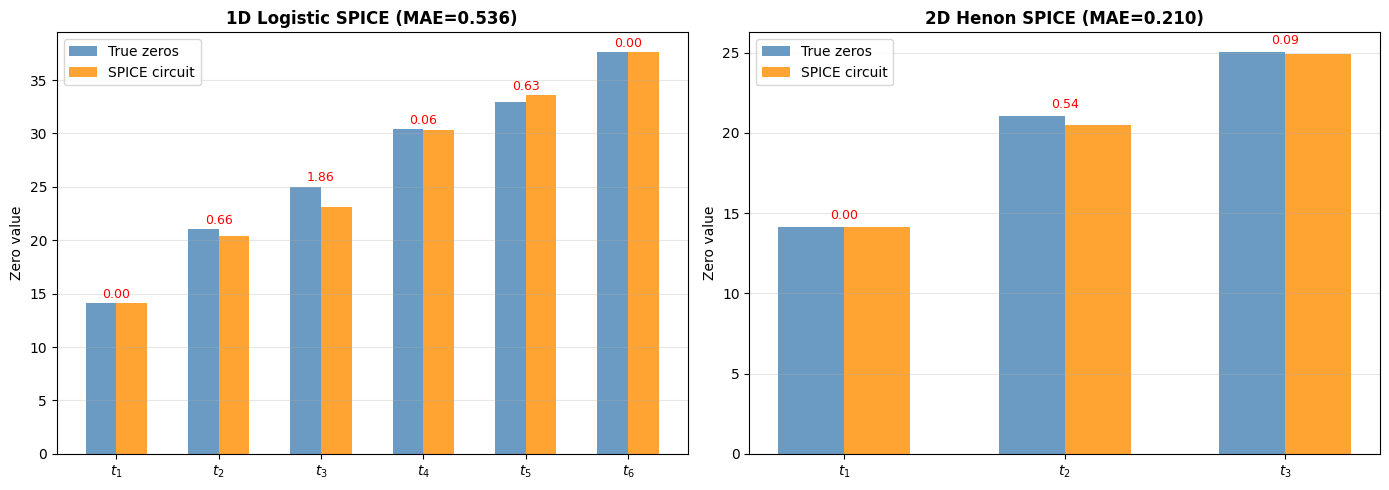

Saved fig2_markov_zeros.png


In [8]:
# 如果你是在 Jupyter Notebook 中运行，建议在 Cell 的最前面加上这行魔法命令（如果你已经加过则不需要重复加）
#%matplotlib inline
import matplotlib.pyplot as plt

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, result in [(axes[0], '1D Logistic', result_log),
                           (axes[1], '2D Henon', result_hen)]:
    pred = result.get('predicted_zeros')
    if pred is not None and len(pred) >= 2:
        n = len(pred)
        x = np.arange(n)
        true = [float(TRUE_ZEROS[i]) for i in range(n)]
        ax.bar(x - 0.15, true, 0.3, label='True zeros', color='steelblue', alpha=0.8)
        ax.bar(x + 0.15, pred, 0.3, label='SPICE circuit', color='darkorange', alpha=0.8)
        for i in range(n):
            ax.text(i, max(true[i], pred[i]) + 0.5,
                    f'{abs(pred[i]-true[i]):.2f}', ha='center', fontsize=9, color='red')
        ax.set_xticks(x)
        ax.set_xticklabels([f'$t_{{{i+1}}}$' for i in range(n)])
        ax.legend()
    ax.set_ylabel('Zero value')
    ax.set_title(f'{label} SPICE (MAE={result["mae"]:.3f})', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig2_markov_zeros.png', dpi=200)
plt.show()
print('Saved fig2_markov_zeros.png')